In [50]:
from pathlib import Path

import pandas as pd
import numpy as np

# Localizar raíz del proyecto
ROOT = Path.cwd()

while not (ROOT / "src" / "database" / "TFM.duckdb").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError(
            "No se ha encontrado la raíz del proyecto."
        )
    ROOT = ROOT.parent

DATA_PATH = (
    ROOT
    / "data"
    / "modeling"
    / "dataset_mag14_t1.parquet"
)

df = pd.read_parquet(DATA_PATH)

print(f"Dataset cargado: {df.shape}")

Dataset cargado: (23556, 111)


# 0. EDA

In [ ]:
VARIABLES_METEO = ['direccion_racha_max',
                    'humedad_max',
                    'humedad_media',
                    'humedad_min',
                    'precipitacion',
                    'presion_max',
                    'presion_min',
                    'temp_max',
                    'temp_media',
                    'temp_min',
                    'viento_racha',
                    'viento_velocidad']

In [51]:
df["target_mag_14"].describe()

count    23556.000000
mean        53.902590
std         23.585672
min          1.208333
25%         36.203274
50%         56.190833
75%         71.963003
max        124.833333
Name: target_mag_14, dtype: float64

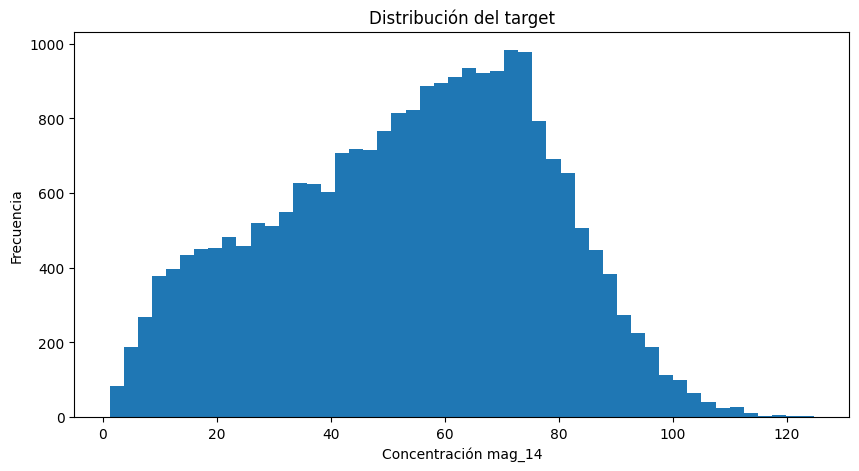

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["target_mag_14"],
    bins=50
)

plt.xlabel("Concentración mag_14")
plt.ylabel("Frecuencia")
plt.title("Distribución del target")

plt.show()

In [53]:
station_stats = (
    df.groupby("estacion")["target_mag_14"]
    .agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    .round(2)
)

display(station_stats)

,count,mean,std,min,median,max
estacion,,,,,,
8,1812,51.06,21.95,1.83,52.36,107.00
16,1812,53.73,23.68,2.24,55.67,115.33
17,1812,50.55,23.20,1.71,53.66,106.88
18,1812,52.86,24.12,1.73,56.02,112.08
24,1812,57.66,24.08,1.50,60.32,124.83
27,1812,51.33,23.32,1.21,55.02,110.83
35,1812,54.47,24.10,1.33,57.29,110.43
39,1812,54.03,24.24,2.12,55.14,121.42
49,1812,53.84,23.21,1.79,56.46,111.92


<Figure size 1200x500 with 0 Axes>

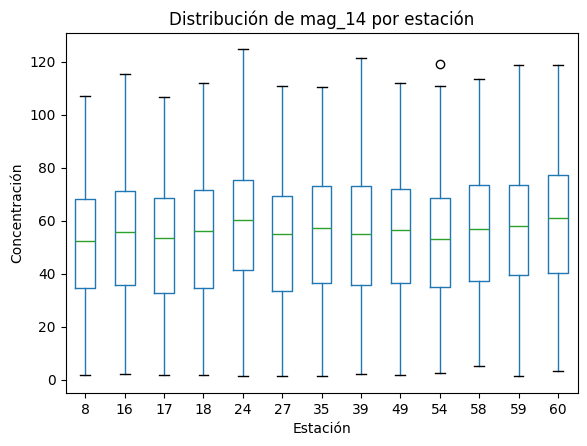

In [54]:
plt.figure(figsize=(12, 5))

df.boxplot(
    column="target_mag_14",
    by="estacion",
    grid=False
)

plt.title("Distribución de mag_14 por estación")
plt.suptitle("")
plt.xlabel("Estación")
plt.ylabel("Concentración")

plt.show()

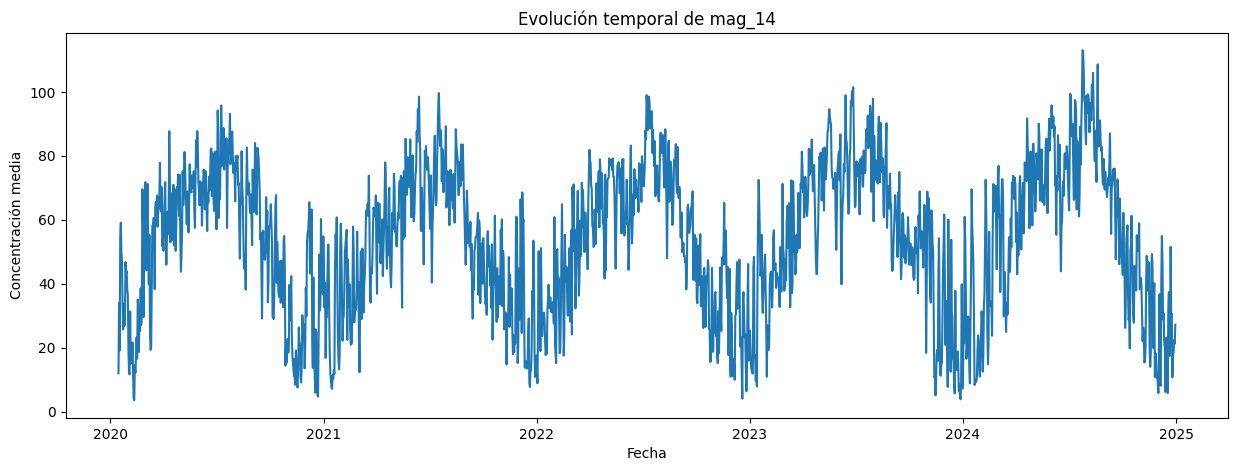

In [55]:
daily_target = (
    df.groupby("fecha")["target_mag_14"]
    .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_target.index,
    daily_target.values
)

plt.xlabel("Fecha")
plt.ylabel("Concentración media")
plt.title("Evolución temporal de mag_14")

plt.show()

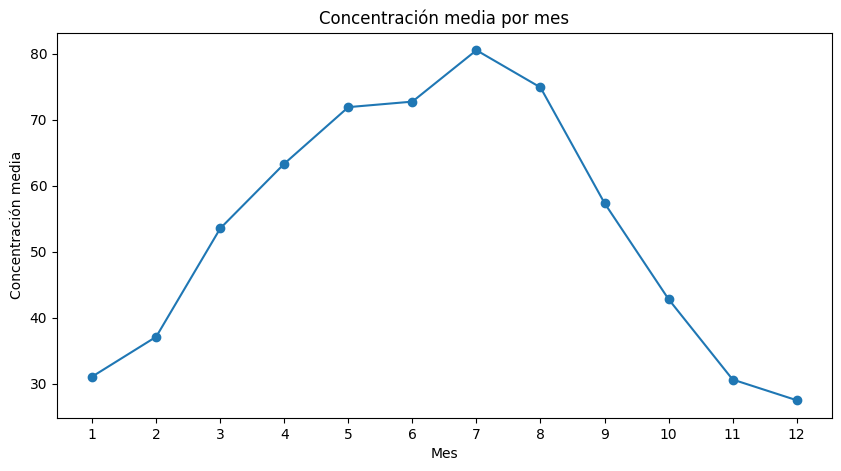

In [56]:
monthly = (
    df.groupby("month")["target_mag_14"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.xlabel("Mes")
plt.ylabel("Concentración media")
plt.title("Concentración media por mes")
plt.xticks(range(1, 13))

plt.show()

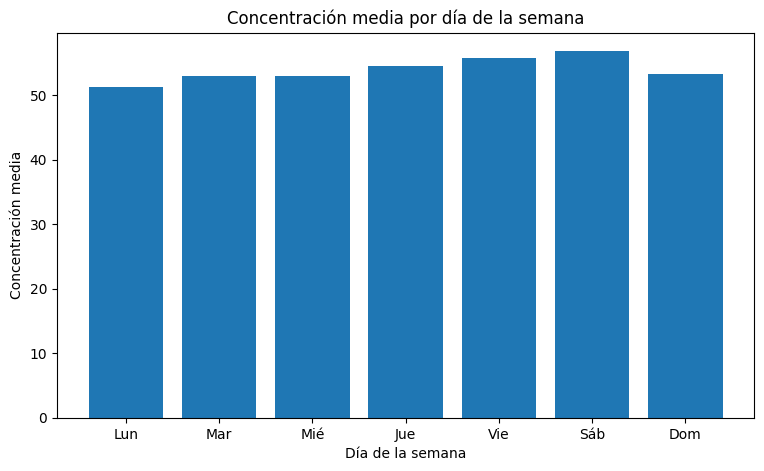

In [57]:
dow = (
    df.groupby("day_of_week")["target_mag_14"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.bar(
    dow.index,
    dow.values
)

plt.xlabel("Día de la semana")
plt.ylabel("Concentración media")
plt.title("Concentración media por día de la semana")
plt.xticks(range(7), [
    "Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"
])

plt.show()

In [58]:
lag_corr = df[
    [
        "target_mag_14",
        "mag_14_lag_0",
        "mag_14_lag_1",
        "mag_14_lag_2",
        "mag_14_lag_3",
        "mag_14_lag_7",
        "mag_14_lag_14"
    ]
].corr()["target_mag_14"].sort_values(ascending=False)

display(lag_corr)

target_mag_14    1.000000
mag_14_lag_0     0.854171
mag_14_lag_1     0.765653
mag_14_lag_2     0.728557
mag_14_lag_3     0.698949
mag_14_lag_7     0.679674
mag_14_lag_14    0.624677
Name: target_mag_14, dtype: float64

In [59]:
current_meteo = [
    f"{col}_lag_0"
    for col in METEO_VARIABLES
    if f"{col}_lag_0" in df.columns
]

corr_meteo = (
    df[["target_mag_14"] + current_meteo]
    .corr()["target_mag_14"]
    .drop("target_mag_14")
    .sort_values()
)

display(corr_meteo)

NameError: name 'METEO_VARIABLES' is not defined